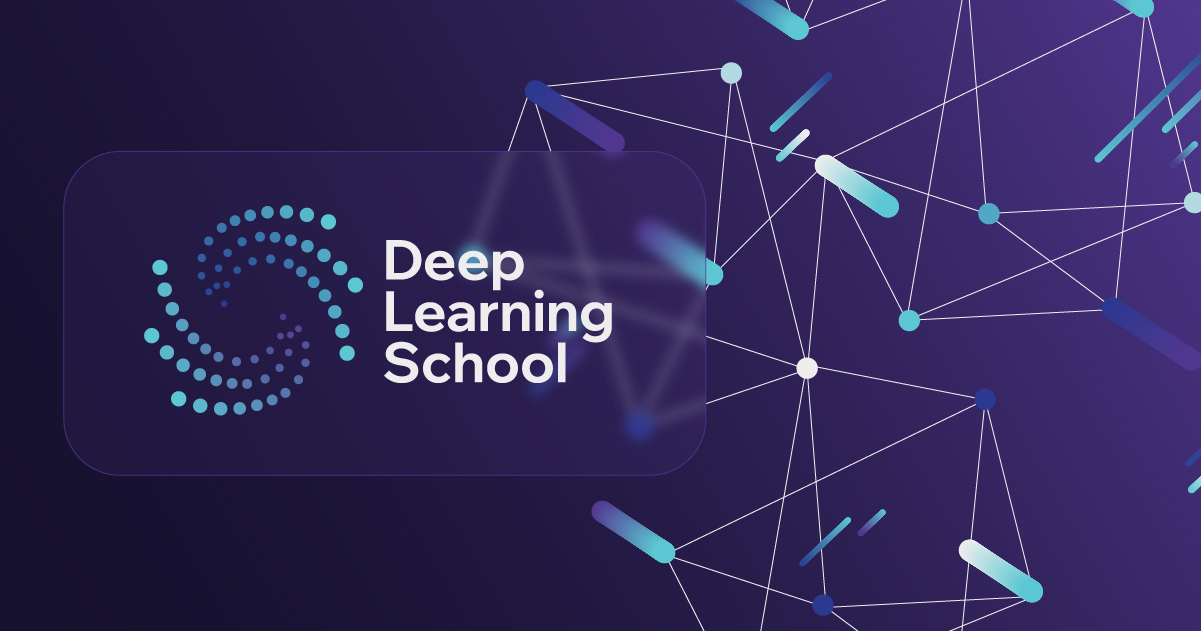

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Полносвязные и свёрточные нейронные сети</b></h1>



В этом занятии нам предстоит потренироваться построению нейронных сетей с помощью библиотеки Pytorch. Делать мы это будем на нескольких датасетах.

Для каждого датасета мы будет реализовывать стандартную логику обучения моделей:
1. Подготовим данные
2. Создадим модель (напишем класс модели)
3. Создадим функции обучения на тренировочных данных и применения модели к тестовым данным
4. Проведем обучение, оценим результаты работы моделей

In [1]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import TensorDataset, DataLoader
import random
from tqdm.notebook import tqdm

import copy

sns.set(style="darkgrid", font_scale=1.4)

In [2]:
# Reduce stochasticity

SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

In [3]:
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

# Часть 1. Датасет moons

## Часть 1.1. Подготовка данных
Давайте сгенерируем датасет и посмотрим на него!

In [4]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)

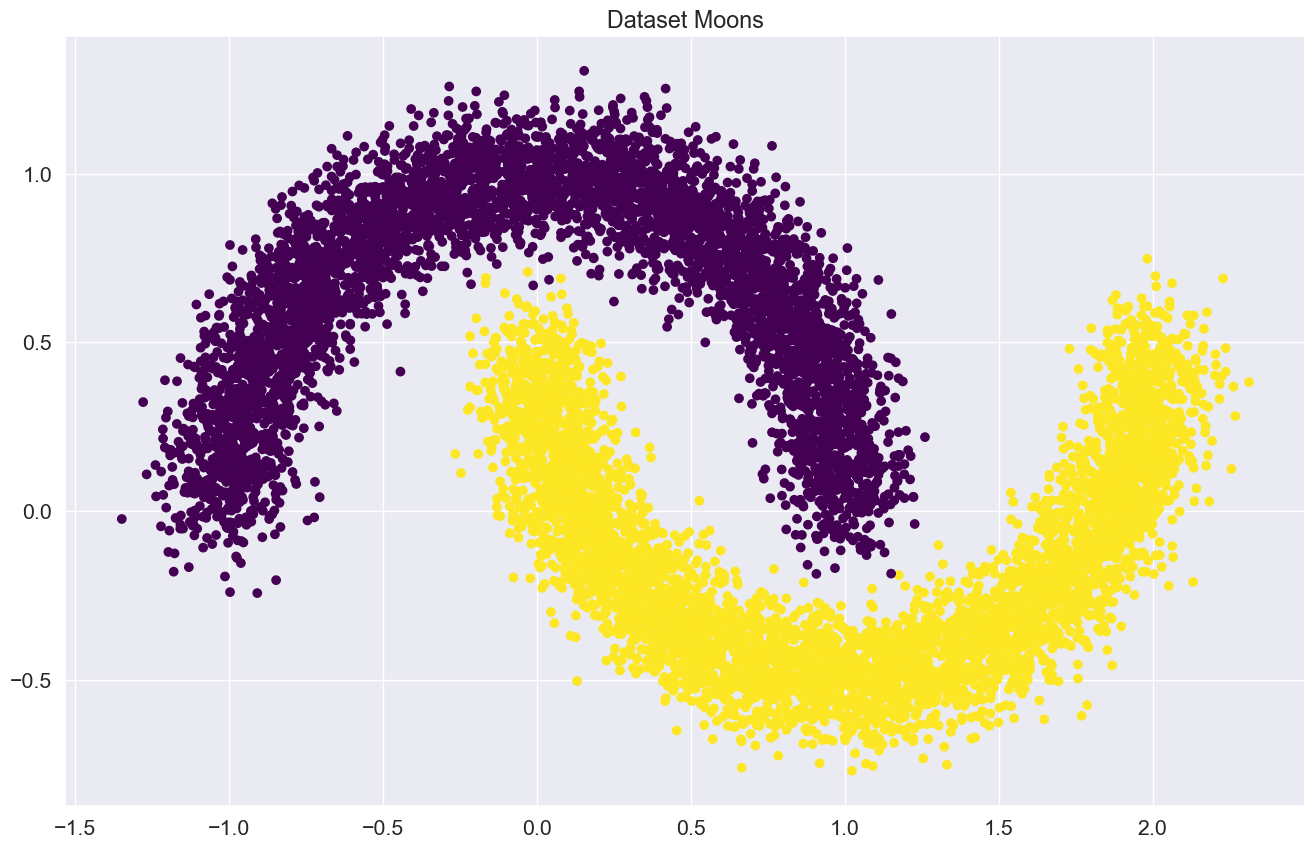

In [5]:
plt.figure(figsize=(16, 10))
plt.title('Dataset Moons')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Задание. Загрузчики данных
В PyTorch загрузка данных как правило происходит налету (иногда датасеты не помещаются в оперативную память). Для этого используются две сущности `Dataset` и `DataLoader`.

1.   `Dataset` загружает каждый объект по отдельности.

2.   `DataLoader` группирует объекты из `Dataset` в батчи.

Так как наш датасет достаточно маленький мы будем использовать `TensorDataset`. Все, что нам нужно, это перевести из массива numpy в тензор с типом `torch.float32`.

Создайте тензоры с обучающими и тестовыми данными

In [7]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)  

X_val_t = torch.tensor(X_test, dtype=torch.float32)
y_val_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)  

Создаем `Dataset` и `DataLoader`.

Подумайте, нужно ли использовать `shuffle` для:


*   train data
*   validation data

Почему вы приняли такое решение?

`shuffle` я буду использовать на тренировочных данных, так как при обучении желательно перемешивать данные, чтобы нейронная сеть лучше обобщилась. однако на валидационной выборке лучше не использовать перемешивание, поэтому будет делать это только на Train Dataset




In [8]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)

## Часть 1.2. Класс модели
**Напоминание.** Давайте вспоним, что происходит в логистической регрессии. На входе у нас есть матрица объект-признак $X$ и столбец-вектор $y$ – метки из $\{0, 1\}$ для каждого объекта. Мы хотим найти такую матрицу весов $W$ и смещение $b$ (bias), что наша модель $XW + b$ будет каким-то образом предсказывать класс объекта. Как видно, на выходе наша модель может выдавать число в интервале от $(-\infty;\infty)$. Этот выход как правило называют "логитами" (logits). Нам необходимо перевести его на интервал от $[0;1]$ для того, чтобы он выдавал нам вероятность принадлежности объекта к классу 1, также лучше, чтобы эта функция была монотонной, быстро считалась, имела производную и на $-\infty$ имела значение $0$, а на $+\infty$ имела значение $1$. Такой класс функций называется сигмоидой. Чаще всего в качестве сигмоиды берут:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

Модель логистической регрессия - это по сути **нейронная сеть**  с одним линейным слоем и функцией активации сигмоида. Обученная модель возвращает прогнозы вероятностей классов для каждого обхекта, по которым можно рассчитать наиболее вероятный класс для каждого объекта.

В первой части задания мы на этой знакомой нам модели потренируем технику работы с нейронными сетями.

### Задание. Реализация логистической регрессии

Вам необходимо написать модуль на PyTorch, реализующий линейную модель для расчета $logits = XW + b$, где $W$ и $b$ – параметры (`nn.Parameter`) модели. Иначе говоря, здесь мы реализуем своими руками модуль `nn.Linear` (в этом пункте его использование запрещено). Инициализируйте веса нормальным распределением (`torch.randn`).

In [9]:
class LinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(in_features, out_features))
        self.bias = bias
        if bias:
            self.bias_term = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        x =  torch.matmul(x, self.weights)
        if self.bias:
            x += self.bias_term
        return x

In [10]:
linear_regression = LinearRegression(in_features = 2, out_features = 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.05)

**Вопрос 1.** Сколько обучаемых параметров у получившейся модели? Имеется в виду суммарное количество отдельных числовых переменных, а не количество тензоров.

**Ответ:** 3 `(weights = 2, bias = 1)`

In [11]:
for name, param in linear_regression.state_dict().items():
    print(f"{name}: {param}")

weights: tensor([[0.3367],
        [0.1288]])
bias_term: tensor([0.])


## Часть 1.3. Функции для работы с моделью (обучение и предсказание)

### Задание. Функция обучения

Перейдём непосредственно к обучению.

Вот псевдокод, который поможет вам разобраться в том, что происходит во время обучения

```python
for epoch in range(max_epochs):  # <----------- итерируемся по датасету несколько раз
    for x_batch, y_batch in dataset:  # <------ итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
        optimizer.zero_grad()  # <------------- обнуляем градиенты модели
        outp = model(x_batch)  # <------------- получаем "логиты" из модели
        loss = loss_func(outp, y_batch)  # <--- считаем "лосс" для логистической регрессии
        loss.backward()  # <------------------- считаем градиенты
        optimizer.step()  # <------------------ делаем шаг градиентного спуска
        if convergence:  # <------------------- в случае сходимости выходим из цикла
            break
```

В коде ниже добавлено логирование `accuracy`.

Реализуем цикл обучения в виде функции, которая будет принимать в качестве параметров нашу модель, данные (созданный ранее DataLoader), оптимизатор и функцию потерь и проводить обучение (т.е. пересчитывать и обновлять веса модели) до выполнения определенных условий. Функция будет возвращать список из лоссов на всех батчах в цикле обучения и список из наборов всех значений параметров модели (weights и bias_term) по всем эпохам цикла обучения.

Значения параметров мы будем сохранять на случай, если модель переобучится и будут нужны не последние значения, а более старые. Можно было бы сохранять значения параметров не по всем, а по нескольким последним эпохам, но для простоты сохраним по всем эпохам.

Цикл обучения будет остановливаться при выполнении одного из двух условий:
- достижение максимального количества эпох
- замедление снижения валидационной метрики (например, чтобы модель не переобучилась).

Поскольку пока мы с вами еще не определились с метрикой, давайте следить за изменением `loss` (остановка цикла, если разность между усредненными значениями loss в текущей и предыдущей эпохах меньше определенного порога)

Максимальное количество эпох и порог, с которым будем сравнивать разницу усредненных значений loss между эпохами, мы также будем передавать в функцию в качестве параметров.  

**Комментарий**

Следить и сравнивать изменение `train loss` может не всегда корректно отображать ситуацию с обучением. Например, иногда в диффузионных моделях при обучении функция потерь довольно быстро начинает колебаться в окресности одного значения, однако качество генерации картинок еще долго может улучшаться. Однако в данном примере можно использовать прекращение изменения лосса как критерий остановки.

In [12]:
def train_model(model, train_dataloader, optimizer, loss_func, max_epochs, tol = 1e-3):
  '''
  args:
    model - модель для обучения
    train_dataloader - loader с обучающей выборкой
    optimizer - оптимизатор, взятый из модуля `torch.optim`
    loss_func - функция потерь, взятая из модуля `torch.nn`
    max_epochs - максимальное количество эпох обучения
    tol - порог, с которым будет сравниваться изменение loss, усредненного по эпохе
  '''

  # создадим переменные (на данный момент - пустые списки), куда будем сохранять
  # лоссы по батчам, усредненные по эпохе лоссы и параметры модели
  batch_losses = []
  epoch_mean_losses = []
  model_param_dict = []

  for epoch in range(max_epochs):
    losses = []    # переменная losses - список, куда будем добавлять значения loss по каждому батчу текущей эпохи
    for it, (X_batch, y_batch) in enumerate(train_dataloader):
        # Далее далее по коду идут стандартные операции цикла обучения:
        optimizer.zero_grad()
        outp = model(X_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        losses.append(loss.item())
        optimizer.step()

        # Для расчета accuracy вычисляем вероятности и предсказание класса нашей моделью,
        # затем вычисляем среднее значение accuracy для текущего батча
        probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.float32)
        batch_acc = (preds == y_batch).sum() / y_batch.size(0)

        # через каждые 100 батчей выводим среднее значение accuracy по батчу
        if (epoch * len(train_dataloader) + it + 1) % 100 == 0:
            print(f"Iteration: {epoch * len(train_dataloader) + it + 1}\nBatch accuracy: {batch_acc}")

    batch_losses = batch_losses + losses    # добавляем список лоссов текущей эпохи к списку лоссов по батчам всех предыдущих эпох
    epoch_mean_losses.append(sum(losses)/len(losses))    # вычисляем средний по текущей эпохе лосс и добавляем к списку по предыдущим эпохам
    model_param_dict.append(copy.deepcopy(model.state_dict()))    # добавляем в список текущие значения параметров модели

    # Ниже реализован ранний выход из цикла обучения. Если разница между средним по эпохе значением loss в текущей
    # и предыдущей эпохах меньше порога tol, то оператор return завершит выполнение функции и обучение прекратится
    if epoch > 0 and abs(epoch_mean_losses[-1] - epoch_mean_losses[-2]) < tol:
          print(f"\nIteration: {epoch * len(train_dataloader) + it +1}. Convergence. Stopping iterations after {epoch + 1} epochs.")
          return batch_losses, model_param_dict

  return batch_losses, model_param_dict

Теперь давайте проверим нашу функцию. Запустим обучение с лимитом 100 эпох.

**Замечание.** Если вы захотите запустить обучение модели заново, не забудьте снова инициировать модель и оптимайзер. Если этого не сделать, функция train_model() будет пытаться обновлять веса уже обученной ранее модели - то есть пытаться дообучить нашу модель. Если же мы сначала заново инициируем модель, ее веса обновятся на случайные значения (см. строки self.weights = nn.Parameter(...) и self.bias_term = nn.Parameter(...) в функции инициализации `__init__()`) и обучение будет происходить с нуля.

  

In [13]:
losses, model_param_dict = train_model(model = linear_regression, 
                                       train_dataloader = train_dataloader,
                                       optimizer = optimizer,
                                       loss_func = loss_function,
                                       max_epochs = 100,
                                       tol = 1e-3)

Iteration: 100
Batch accuracy: 0.8125
Iteration: 200
Batch accuracy: 0.7890625
Iteration: 300
Batch accuracy: 0.859375
Iteration: 400
Batch accuracy: 0.8203125
Iteration: 500
Batch accuracy: 0.8828125
Iteration: 600
Batch accuracy: 0.84375
Iteration: 700
Batch accuracy: 0.796875
Iteration: 800
Batch accuracy: 0.8671875
Iteration: 900
Batch accuracy: 0.84375
Iteration: 1000
Batch accuracy: 0.84375
Iteration: 1100
Batch accuracy: 0.84375
Iteration: 1200
Batch accuracy: 0.8671875
Iteration: 1300
Batch accuracy: 0.8828125
Iteration: 1400
Batch accuracy: 0.875
Iteration: 1500
Batch accuracy: 0.84375
Iteration: 1600
Batch accuracy: 0.8828125

Iteration: 1652. Convergence. Stopping iterations after 28 epochs.


In [14]:
list(linear_regression.parameters())

[Parameter containing:
 tensor([[ 1.2272],
         [-3.7664]], requires_grad=True),
 Parameter containing:
 tensor([0.2807], requires_grad=True)]

**Вопрос 2.** Сколько итераций потребовалось, чтобы алгоритм сошелся? 

**Ответ:** Всего 1652 итераций и 28 эпох

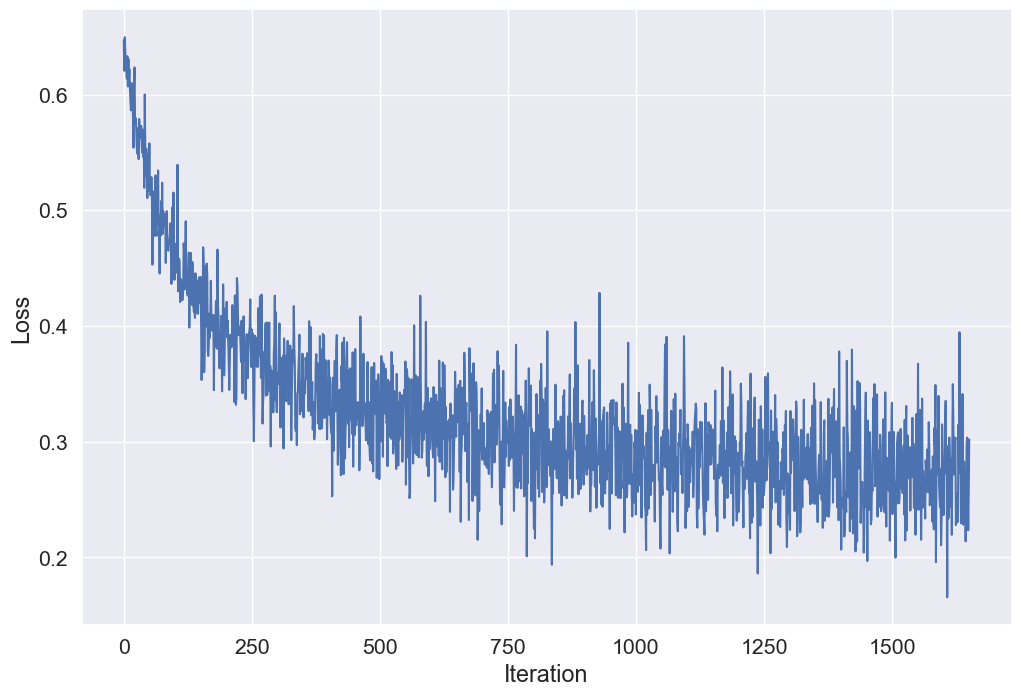

In [15]:
plt.figure(figsize=(12, 8))
plt.plot(range(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

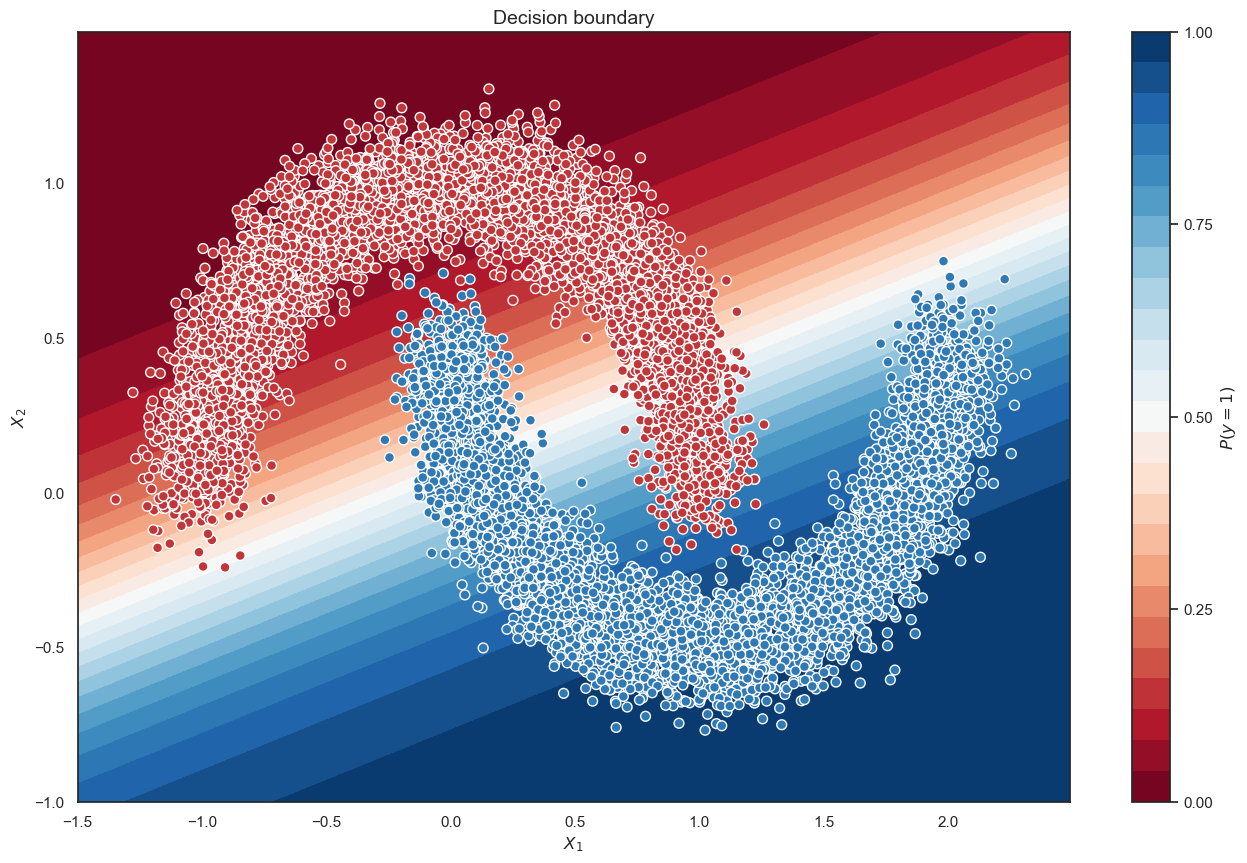

In [16]:
import numpy as np

sns.set(style="white")

xx, yy = np.mgrid[-1.5:2.5:.01, -1.:1.5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
batch = torch.from_numpy(grid).type(torch.float32)
with torch.no_grad():
    probs = torch.sigmoid(linear_regression(batch).reshape(xx.shape))
    probs = probs.numpy().reshape(xx.shape)

f, ax = plt.subplots(figsize=(16, 10))
ax.set_title("Decision boundary", fontsize=14)
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:,0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(xlabel="$X_1$", ylabel="$X_2$")
plt.show()

### Задание. Применим обученную модель к тестовым данным
Реализуйте функцию predict и посчитайте accuracy на test. Функция должна возвращать предсказание наиболее вероятного класса для каждого объекта из валидационой выборки:

In [17]:
@torch.no_grad()
def predict(dataloader, model):
    predictions = np.array([])
    for x_batch, y_batch in dataloader:
        outp = model(x_batch)
        probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.float32)
        acc = (preds == y_batch).sum() / y_batch.size(0)
        predictions = np.append(predictions, preds.cpu().numpy())
    print(f"Test Accuracy: {acc:.4f}")
    return predictions

In [18]:
test = predict(val_dataloader, linear_regression)

Test Accuracy: 0.8676


In [19]:
from sklearn.metrics import accuracy_score

model = linear_regression
y_true = []
y_pred = []
with torch.no_grad():  
    for x_batch, y_batch in val_dataloader:
        outputs = model(x_batch)
        probabilities = torch.sigmoid(outputs)
        batch_pred = (probabilities > 0.5).float()
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(batch_pred.cpu().numpy().flatten())
accuracy = accuracy_score(y_true, y_pred)
print(f'Test Accuracy = {accuracy:.4f}')

Test Accuracy = 0.8852


**Вопрос 3**

Какое `accuracy` получается после обучения? (ваш ответ может варьироваться в зависимости от запуска)

**Ответ:** при первом рассчете он вывел значение 0.8676, но оно рассчитывалось на последнем батче, тогда как accuracy_score рассчитал среднюю точность на каждом батче 

# Часть 2. Датасет MNIST

## Часть 2.1. Подготовка данных
Датасет MNIST содержит рукописные цифры. Загрузим датасет и создадим DataLoader-ы. Пример можно найти в семинаре по полносвязным нейронным сетям.

In [20]:
import os 
from torchvision.datasets import MNIST
from torchvision import transforms as tfs
from torch.utils.data import DataLoader

data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5,), (0.5,))
])

root = './'
train_dataset_MNIST = MNIST(
    root, 
    train=True,  
    transform=data_tfs, 
    download=True
)
val_dataset_MNIST  = MNIST(
    root, 
    train=False, 
    transform=data_tfs, 
    download=True
)
train_dataloader_MNIST = DataLoader(
    train_dataset_MNIST, 
    batch_size=128, 
    shuffle=True
)
valid_dataloader_MNIST = DataLoader(
    val_dataset_MNIST, 
    batch_size=128, 
    shuffle=False
)
loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

## Часть 2.2. Полносвязные нейронные сети
Сначала решим MNIST с помощью полносвязной нейронной сети.

### Задание. Модель простой полносвязной нейронной сети

Создайте полносвязную нейронную сеть с помощью класса Sequential. Сеть состоит из:
* Уплощения матрицы в вектор (nn.Flatten);
* Двух скрытых слоёв из 128 нейронов с активацией nn.ELU;
* Выходного слоя с 10 нейронами.


In [21]:
activation = nn.ELU()
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    activation, 
    nn.Linear(128, 10)
)

Задайте лосс для обучения (кросс-энтропия).

Вспомним, что такое кросс-энтропийная функция потерь:

$$
L = -\frac{1}{N} \sum_{n=1}^{N} \sum_{i=1}^{C} y_{ni} \log(\hat{y}_{ni})
$$

где:
- $N$ — количество объектов в выборке,
- $C$ — количество классов,
- $y_{ni}$ — истинная метка (one-hot представление),
- $\hat{y}_{ni}$ — предсказанная вероятность модели для класса $i$ на примере $n$.

***Пример расчета***

Рассмотрим пример расчета кросс-энтропийной функции потерь для задачи многоклассовой классификации с 10 классами. Предположим, что у нас есть один объект, истинный класс которого известен, а модель выдала свои предсказания в виде вероятностей для каждого класса.

Пусть объект является цифрой 2. Тогда:
     $$
     y = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
     $$

Пусть модель выдала следующие вероятности для 10 классов:  
     $$
     \hat{y} = [0.1, 0.05, 0.6, 0.15, 0.05, 0.02, 0.01, 0.01, 0.01, 0.0]
     $$

$$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$



Только один элемент $y_i$ равен 1, остальные равны 0. Поэтому:

$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i) = - y_2 \cdot log(\hat{y}_2) = - 1 \cdot log(0.6) \approx 0.51
$

In [22]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [23]:
# for epoch in range(max_epochs):
#     model.train()
#     for x_batch, y_batch in train_dataloader:
#         optimizer.zero_grad()
#         outp = model(x_batch)
#         loss = criterion(outp, y_batch)
#         loss.backward()
#         count_metrics(outp, y_batch)
#     model.eval()
#     for x_batch, y_batch in valid_dataloader:
#         with torch.no_grad():
#             outp = model(x_batch)
#             count_metrics(outp, y_batch)

In [88]:
def fit_epoch(model, train_dataloader, optimizer, loss_func):
    epoch_correct_predictions = 0.0
    epoch_all_predictions = 0.0
    for X_batch, y_batch in tqdm(train_dataloader):
        optimizer.zero_grad()
        outp = model(X_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        optimizer.step()
        preds = outp.argmax(-1)
        batch_correct_predictions = (preds == y_batch).sum().item()
        batch_all_predictions = len(preds)
        epoch_correct_predictions += batch_correct_predictions
        epoch_all_predictions += batch_all_predictions
    epoch_accuracy = epoch_correct_predictions/epoch_all_predictions
    return epoch_accuracy

def eval_epoch(model, val_dataloader):
    epoch_correct_predictions = 0.0
    epoch_all_predictions = 0.0
    model.eval()
    for X_batch, y_batch in tqdm(val_dataloader):
        with torch.no_grad():
            outp = model(X_batch)
            preds = outp.argmax(-1)
        batch_correct_predictions = (preds == y_batch).sum().item()
        batch_all_predictions = len(preds)
        epoch_correct_predictions += batch_correct_predictions
        epoch_all_predictions += batch_all_predictions
    epoch_accuracy = epoch_correct_predictions/epoch_all_predictions
    return epoch_accuracy

def train(model, num_epochs, dataloaders, optimizer, loss_func):
    accuracy = {'train': [], 'valid': []}
    best_accuracy = 0
    for epochs in range(num_epochs):
        print(f'Epochs: {epochs+1}')
        accuracy_train_epoch = fit_epoch(
            model = model,
            train_dataloader = dataloaders['train'],
            optimizer = optimizer,
            loss_func = loss_func
        )
        print(f'train accuracy: {accuracy_train_epoch}\n')
        
        accuracy_val_epoch = eval_epoch(
            model = model,
            val_dataloader = dataloaders['valid']
        )
        print(f'valid accuracy: {accuracy_val_epoch}\n')

        accuracy['train'].append(accuracy_train_epoch)
        accuracy['valid'].append(accuracy_val_epoch)
        if accuracy_val_epoch > best_accuracy:
            best_accuracy = accuracy_val_epoch
            torch.save(model.state_dict(), 'cnn.pt')
            print('model saved\n')
    return accuracy

In [25]:
fit_epoch(model = model, train_dataloader = train_dataloader_MNIST, optimizer = optimizer, loss_func = criterion)

  0%|          | 0/469 [00:00<?, ?it/s]

0.8824166666666666

In [26]:
eval_epoch(model = model, val_dataloader = valid_dataloader_MNIST)

  0%|          | 0/79 [00:00<?, ?it/s]

0.9298

In [27]:
optimizer = torch.optim.Adam(model.parameters())
max_epochs = 8
accuracy = train(
    model = model,
    num_epochs = max_epochs,
    dataloaders = loaders_MNIST,
    optimizer = optimizer,
    loss_func = criterion
)

Epochs: 1


  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.9365



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.9498

Epochs: 2


...

valid accuracy: 0.9757

Epochs: 8


  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.9834166666666667



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.9751



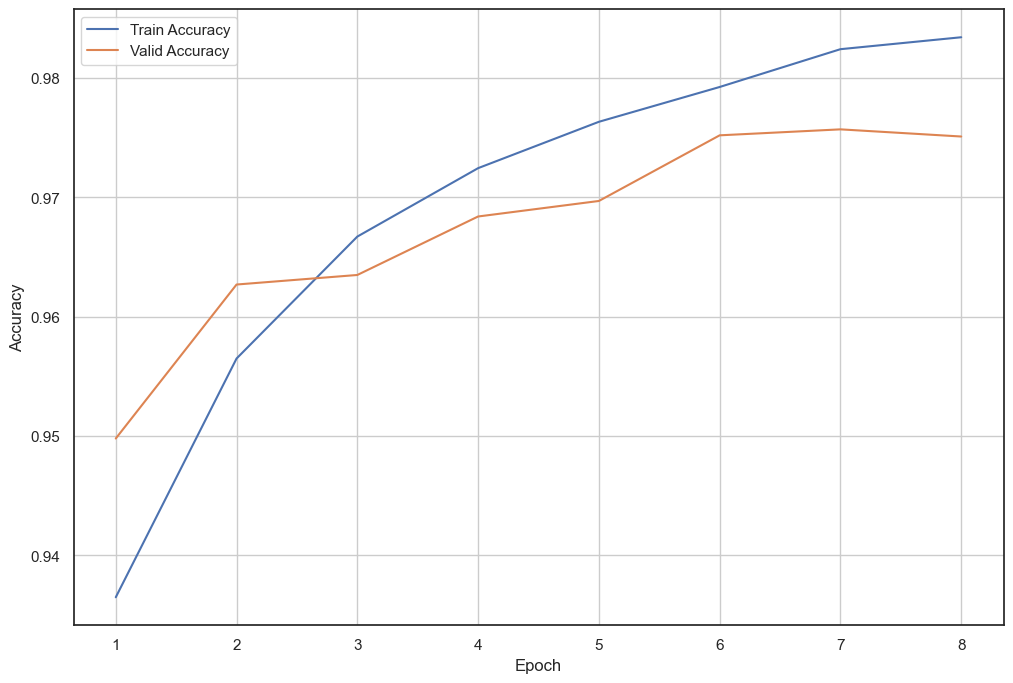

In [28]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, max_epochs + 1),
         accuracy['train'],
         label='Train Accuracy')
plt.plot(range(1, max_epochs + 1),
         accuracy['valid'],
         label='Valid Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Функции активации добавляют ***нелинейность в модель***, что позволяет сети решать сложные задачи, такие как классификация и регрессия. Без функций активации нейронная сеть была бы линейной моделью, так как ***композиция линейных преобразований*** это ***линейное преобразование***.

**ReLU (Rectified Linear Unit)**
   - Формула: $ f(x) = \max(0, x) $
   - Диапазон значений: $ [0, \infty) $

**Leaky ReLU**
   - Формула: $ f(x) = \max(\alpha x, x) $, где $ \alpha $ — маленькое положительное число (обычно $ \alpha = 0.01 $).
   - Диапазон значений: $ (-\infty, \infty) $

**Exponential Linear Unit (ELU)**
   - Формула:
   $f(x) = $
     \begin{cases}
     x & \text{если } x > 0 \\
     \alpha (e^x - 1) & \text{если } x \leq 0
     \end{cases}
   - Диапазон значений:  $ (-\alpha, \infty) $

**Tanh (Гиперболический тангенс)**

  - Формула: $f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
  - Диапазон значений: $(-1, 1)$

**Линейная функция активации**
   - Формула: $ f(x) = x $
   - Диапазон значений: $ (-\infty, \infty) $

   Обратите внимание, что данная функция активации **не добавляет** нелинейности.

#### Задание на дополнительный балл (3 балла)


Давайте попробуем закодировать наши функции активаций, а также потренируемся считать их градиенты.

Напишите классы для каждой из функций активации, а также для градиентов:

1. Leaky ReLU (1.5 балл: 0.5 forward pass, 1 -- backward (grad))

2. Tanh (1.5 балл: 0.5 forward pass, 1 -- backward (grad))

In [29]:
class ReLU(nn.Module):
    def __init__(self, ):
        super().__init__()

    def forward(self, x):
        return torch.maximum(torch.zeros_like(x), x)

    def backward(self, x):
        grads = torch.zeros_like(x)
        grads[x > 0] = 1
        return grads

In [30]:
torch_relu = nn.ReLU()
my_relu = ReLU()

x = torch.linspace(-3, 3, 100, requires_grad=True)

x_relu_my = my_relu(x)
x_relu_torch = torch_relu(x)

assert torch.allclose(x_relu_my, x_relu_torch)

In [31]:
grad_relu_my = my_relu.backward(x)

x_relu_torch.sum().backward()
grad_relu_torch = x.grad.clone()
x.grad.zero_()

assert torch.allclose(grad_relu_my, grad_relu_torch)

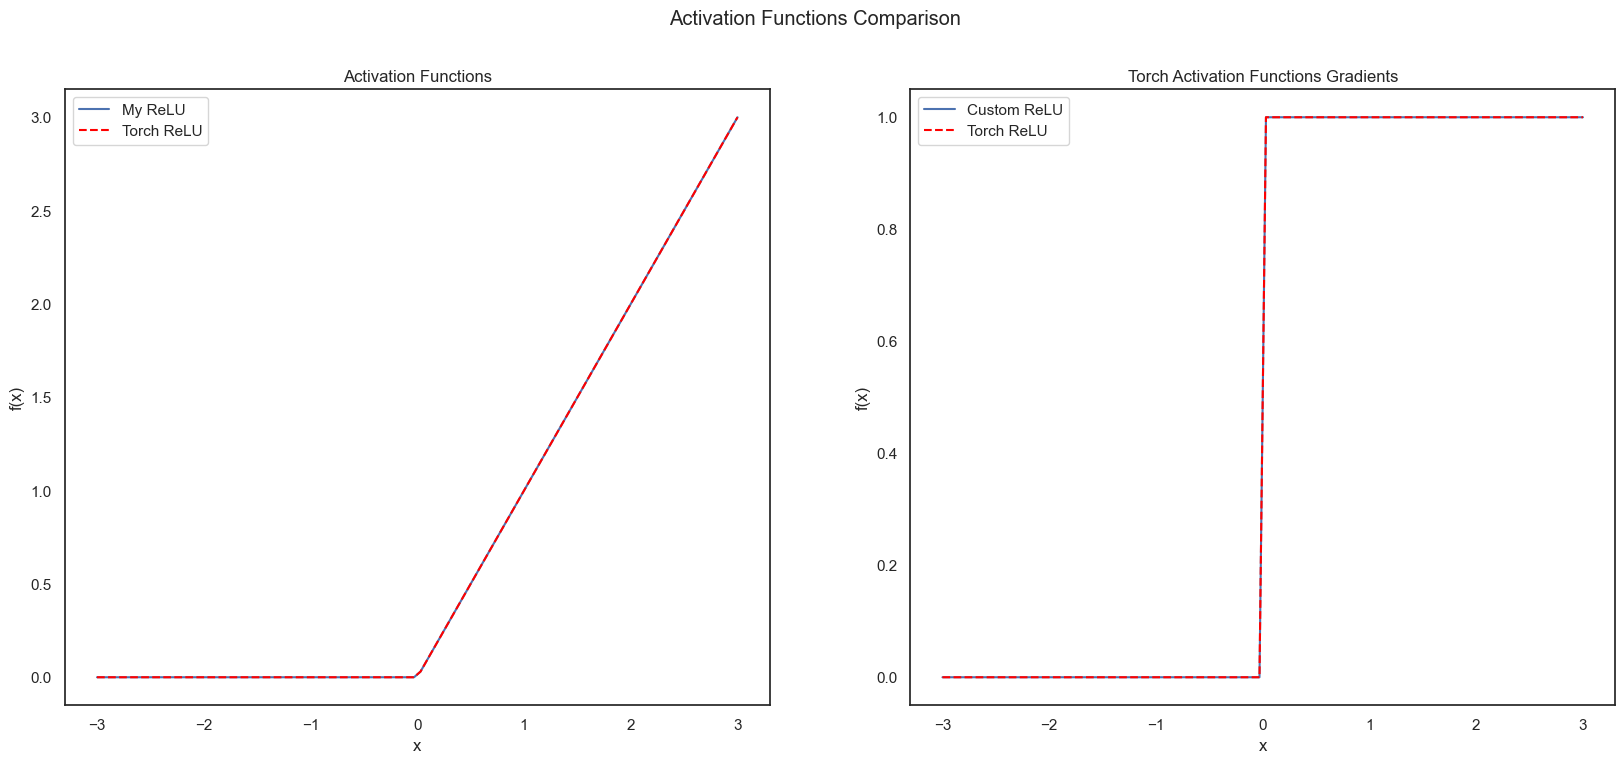

In [32]:
# Plot custom and torch functions
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Activation Functions Comparison")

# Plot Custom Functions
axes[0].set_title("Activation Functions")
axes[0].plot(x.detach().numpy(), x_relu_my.detach().numpy(), label="My ReLU")
axes[0].plot(x.detach().numpy(), x_relu_torch.detach().numpy(), color='red', label="Torch ReLU", linestyle='--')
axes[0].legend()
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")

# Plot Torch Functions
axes[1].set_title("Torch Activation Functions Gradients")
axes[1].plot(x.detach().numpy(), grad_relu_my.detach().numpy(), label="Custom ReLU")
axes[1].plot(x.detach().numpy(), grad_relu_torch.detach().numpy(), color='red', label="Torch ReLU", linestyle='--')
axes[1].legend()
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.show()

In [33]:
class LeakyReLU(nn.Module):
  def __init__(self, alpha):
    super().__init__()
    self.alpha = alpha

  def forward(self, x):
      return torch.maximum(self.alpha * x, x)

  def backward(self, x):
      grads = torch.zeros_like(x)
      grads[x > 0] = 1
      grads[x <= 0] = self.alpha
      return grads

class Tanh(nn.Module):
  def __init__(self, ):
    super().__init__()

  def forward(self, x):
    return torch.tanh(x)

  def backward(self, x):
    grads = 1 - torch.tanh(x)**2
    return grads

In [34]:
torch_leaky_relu = nn.LeakyReLU(negative_slope=0.01)
torch_tanh = nn.Tanh()
your_leaky_relu = LeakyReLU(alpha = 0.01)
your_tanh = Tanh()

In [35]:
x_leaky_custom = your_leaky_relu(x)
x_leaky_torch = torch_leaky_relu(x)
assert torch.allclose(x_leaky_custom, x_leaky_torch)

x_tanh_custom = your_tanh(x)
x_tanh_torch = torch_tanh(x)
assert torch.allclose(x_tanh_custom, x_tanh_torch)

In [36]:
grad_leaky_custom = your_leaky_relu.backward(x)
x.grad.zero_()
x_leaky_torch.sum().backward()
grad_leaky_torch = x.grad.clone()

assert torch.allclose(grad_leaky_custom, grad_leaky_torch)

grad_tanh_custom = your_tanh.backward(x)

x.grad.zero_()
x_tanh_torch.sum().backward()
grad_tanh_torch = x.grad.clone()
assert torch.allclose(grad_tanh_custom, grad_tanh_torch)

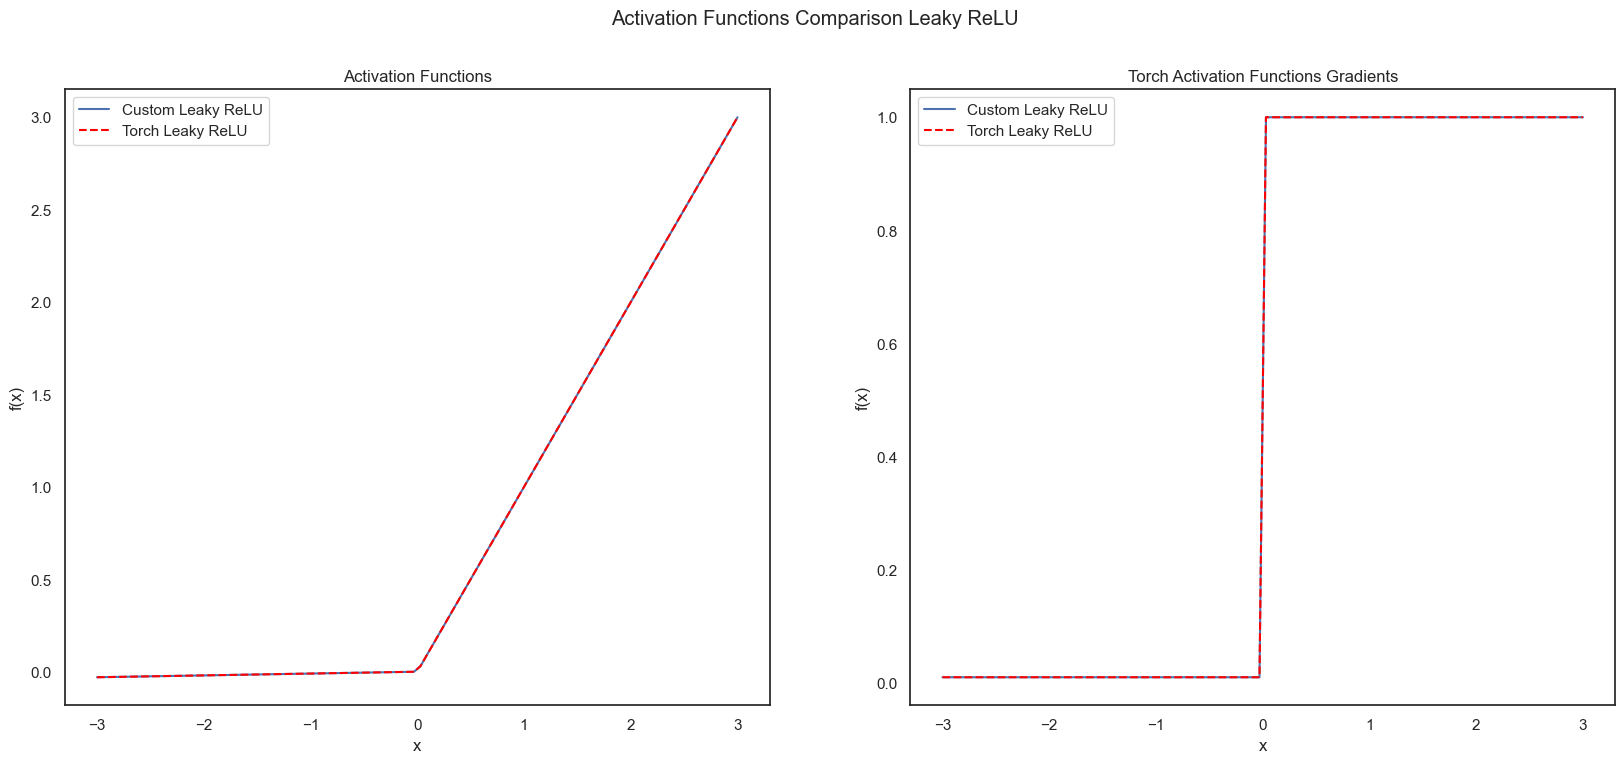

In [38]:
# Plot custom and torch functions
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Activation Functions Comparison Leaky ReLU")

# Plot Custom Functions
axes[0].set_title("Activation Functions")
axes[0].plot(x.detach().numpy(), x_leaky_custom.detach().numpy(), label="Custom Leaky ReLU")
axes[0].plot(x.detach().numpy(), x_leaky_torch.detach().numpy(), color='red', label="Torch Leaky ReLU", linestyle='--')
axes[0].legend()
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")

# Plot Torch Functions
axes[1].set_title("Torch Activation Functions Gradients")
axes[1].plot(x.detach().numpy(), grad_leaky_custom.detach().numpy(), label="Custom Leaky ReLU")
axes[1].plot(x.detach().numpy(), grad_leaky_torch.detach().numpy(), color='red', label="Torch Leaky ReLU", linestyle='--')
axes[1].legend()
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.show()

**Вопрос на подумать:**

Какие недостатки есть у активаций `ReLU` и как эту проблему решает `Leaky ReLU`?

Что происходит с градиентами у активации `Tanh` и как это может помешать обучению?

#### Задание. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

In [41]:
elu_accuracy = accuracy["valid"]

In [46]:
def test_activation_function(activation):
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        activation,
        nn.Linear(128, 10)
        )
    optimizer = torch.optim.Adam(model.parameters())
    accuracy = train(
        model =  model, 
        num_epochs = max_epochs, 
        dataloaders =  loaders_MNIST, 
        optimizer = optimizer, 
        loss_func = criterion
    )
    return accuracy

plain_accuracy = test_activation_function(activation = nn.Identity())['valid'] 
relu_accuracy =  test_activation_function(activation = nn.ReLU())['valid']
leaky_relu_accuracy = test_activation_function(activation = nn.LeakyReLU())['valid']
tanh_accuracy = test_activation_function(activation = nn.Tanh())['valid']

Epochs: 1


  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.8756166666666667



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.8958

Epochs: 2


...

valid accuracy: 0.971

Epochs: 8


  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.9796333333333334



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.9722



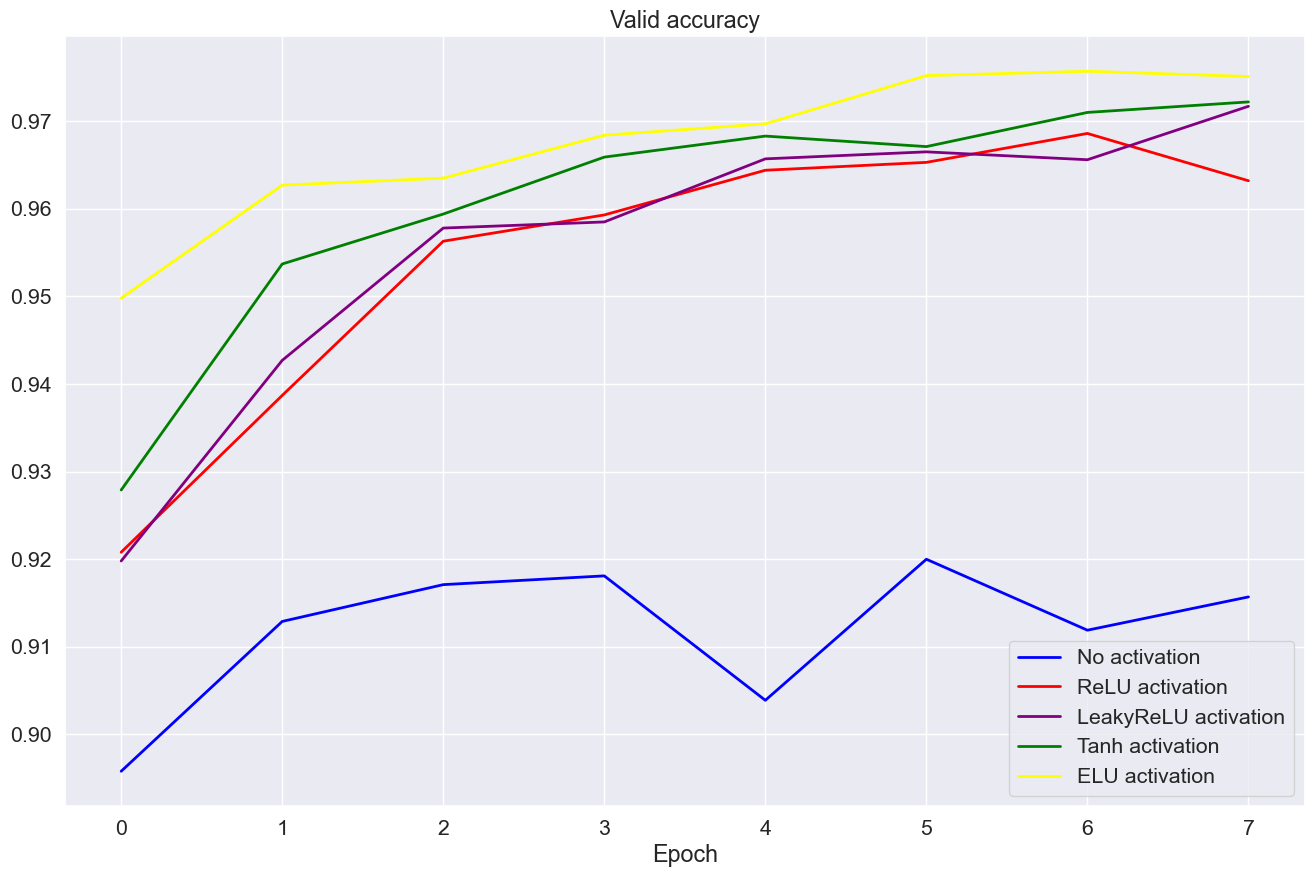

In [50]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy, label="No activation", linewidth=2, color = 'blue')
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2, color = 'red')
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2, color = 'purple')
plt.plot(range(max_epochs), tanh_accuracy, label="Tanh activation", linewidth=2, color = 'green')
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 4.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:** ELU

### Задание. Ядра свёртки
Сначала немного поработам с самим понятием ядра свёртки.

In [53]:
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F

In [60]:
!curl -L "https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg" -o sample_photo.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 49337  100 49337    0     0  42562      0  0:00:01  0:00:01 --:--:-- 42642


In [62]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


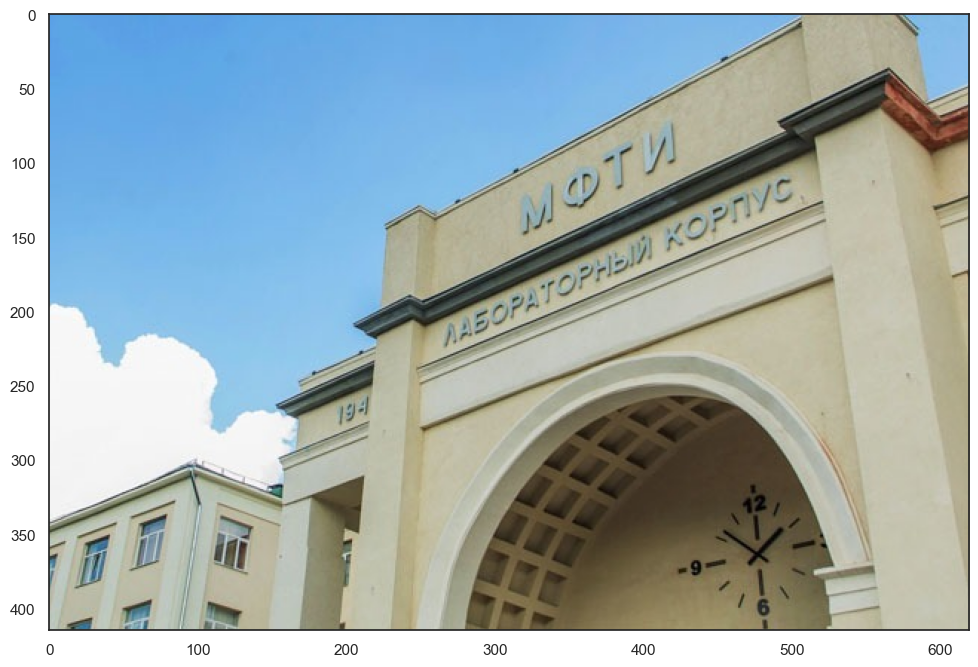

In [63]:
import cv2
sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [65]:
conv_1 = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]) # A
conv_2 = np.array([[0, 1, 0], [0, -2, 0], [0, 1, 0]]) # Б
conv_3 = np.array([[0, 0, 0], [1, -2, 1], [0, 0, 0]]) # В
conv_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]]) # Г
conv_5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]) # Д
conv_6 = np.array([[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]]) # E

In [66]:
def show_conv_transformation(image, convolution):
  img_t = torch.from_numpy(image).type(torch.float32).unsqueeze(0)
  img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
  img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size
  kernel = torch.tensor(convolution).reshape(1, 1, 3, 3).type(torch.float32)
  kernel = kernel.repeat(3, 3, 1, 1)
  result = F.conv2d(img_t, kernel)[0]
  result = torch.clip(input = result, min = 0, max = 256*3)
  plt.figure(figsize=(12, 8))
  result_np = result.permute(1, 2, 0).numpy() / 256 / 3
  plt.imshow(result_np)
  plt.show()
  return None

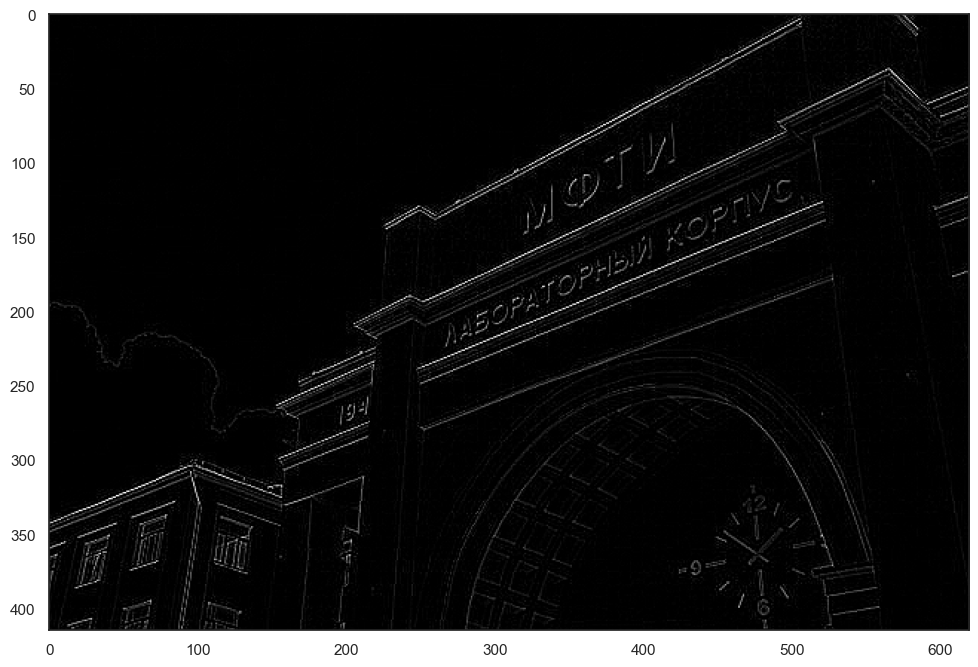

In [74]:
show_conv_transformation(image = RGB_img, convolution = conv_4)

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие

2) Увеличение резкости

3) Тождественное преобразование

4) Выделение вертикальных границ

5) Выделение горизонтальных границ

6) Выделение границ

**Ответ:**

### Задание. Реализуйте класс модели LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [80]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 6, kernel_size = 3)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fl = nn.Flatten()
        self.fc1 = nn.Linear(400, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.fl(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [78]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [90]:
model_LeNet = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet.parameters())
epochs = 7
loaders_MNIST = {"train": train_dataloader_MNIST, "valid": valid_dataloader_MNIST}

### Задание. Обучите CNN-модель
Используйте функцию для обучения модели из части задания про полносвязные нейронные сети.

В качестве возможных улучшений рекомендуем добавить туда:

1. Валидацию каждые `n` шаговь

2. Добавить сохранение промежуточных весов. Может так получиться, что с какого-то момента модель начинает переобучаться и использование весов с более ранних шагов даёт более качественный результат. Именно поэтому полезно сохранять веса не только после последней эпохи, но и с промежуточных этапов обучения.

In [91]:
train(
    model = model_LeNet, 
    num_epochs = epochs, 
    dataloaders = loaders_MNIST, 
    optimizer = optimizer, 
    loss_func = criterion
)

Epochs: 1


  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.9034833333333333



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.9715

model saved

Epochs: 2


...

  0%|          | 0/469 [00:00<?, ?it/s]

train accuracy: 0.9914333333333334



  0%|          | 0/79 [00:00<?, ?it/s]

valid accuracy: 0.9881



{'train': [0.9034833333333333,
  0.9736666666666667,
  0.9816666666666667,
  0.9855,
  0.9879833333333333,
  0.98945,
  0.9914333333333334],
 'valid': [0.9715, 0.9809, 0.9856, 0.9843, 0.9881, 0.9866, 0.9881]}

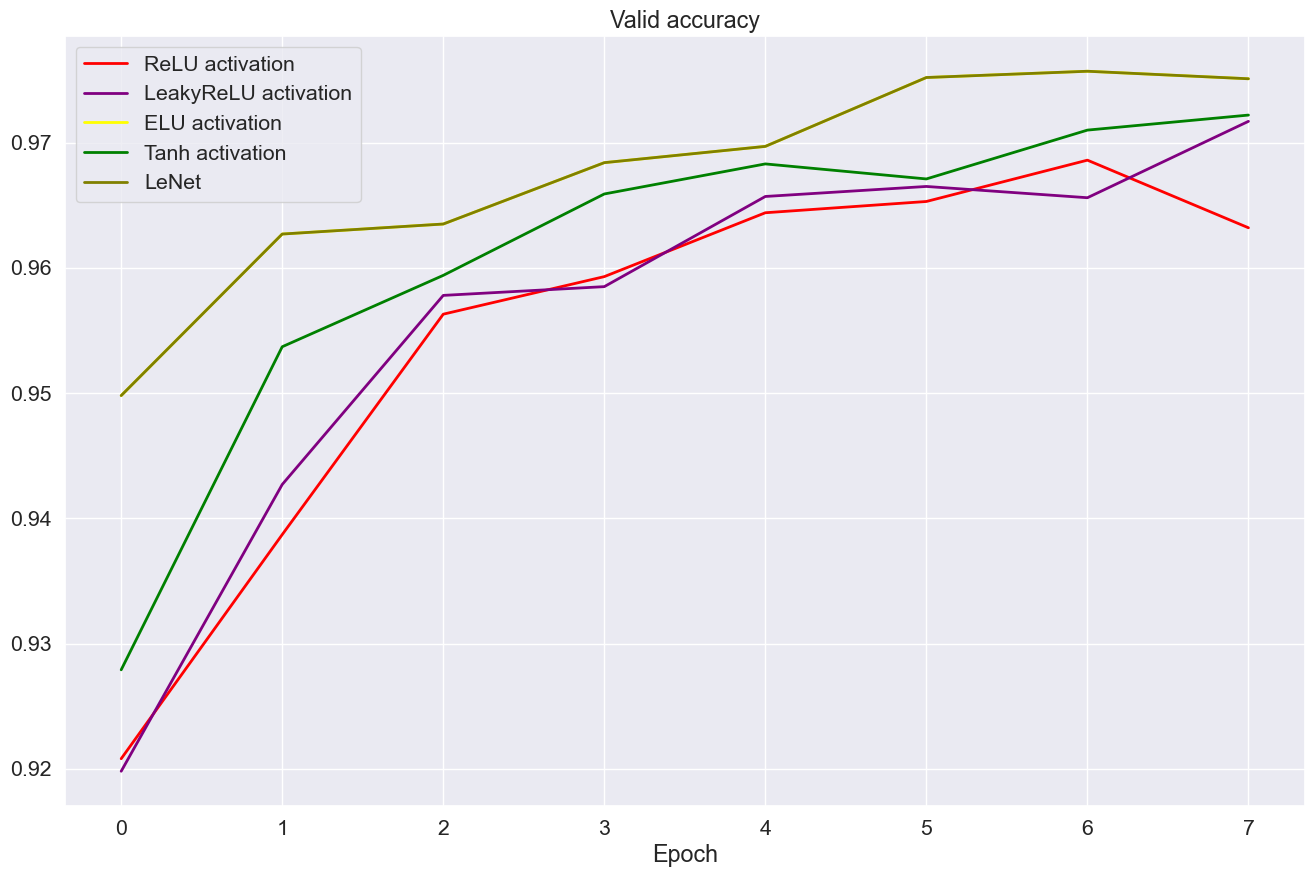

In [94]:
lenet_accuracy = accuracy["valid"]
sns.set(style="darkgrid", font_scale=1.4)
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2, color = 'red')
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2, color = 'purple')
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2, color = 'yellow')
plt.plot(range(max_epochs), tanh_accuracy, label="Tanh activation", linewidth=2, color = 'green')
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2, color = 'olive')
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 6**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:** 0.98 на валидаций, 0.99 на трейне